# BDA (mean-centred PLS)

Barycentric discriminant analysis (BDA; [Abdi and Williams, 2018](https://doi.org/10.1007/978-1-4614-7163-9_110192-2)), also known as mean-centred partial least squares (mean-centred PLS; [Krishnan et al., 2011](https://doi.org/10.1016/j.neuroimage.2010.07.034)) is a tool for identifying multivariate patterns that differentiate between multiple conditions. The basic idea is to perform singular value decomposition on a matrix of condition-wise averages (barycentres) whose columns have been mean-centred.

## Setting up simulated data

We will simulate a dataset with a between-participants condition and a within-participants condition. There will be a main effect of between-participants condition and a main effect of within-participants condition. The pattern of the first effect will be linear over the observed variables and the pattern of the second will be sinusoidal over the observed variables

In [2]:
import numpy as np
import pandas as pd
from pyplsc import BDA
from matplotlib import pyplot as plt

np.random.seed(123)

n_var = 50
n_subj = 30
data = 0.5*np.random.normal(size=(n_subj*2, n_var))
design = pd.DataFrame({
    'group': ['g-a']*n_subj + ['g-b']*n_subj,
    'cond': ['c-a', 'c-b']*n_subj,
    'subj': np.cumsum([1, 0]*n_subj)
})
between_effect = np.arange(n_var)/n_var - 0.5 # Linear pattern over observed variables
within_effect = np.sin(0.2*np.arange(n_var)) # Sinusoidal pattern over observed variables
data[design['group'] == 'g-b'] += between_effect
data[design['cond'] == 'c-b'] += within_effect

We can visualize each of these patterns as follows:

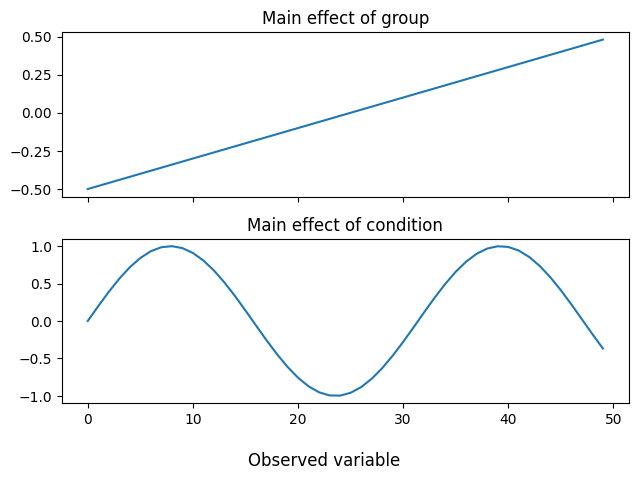

In [28]:
f, ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(between_effect)
ax[0].set_title('Main effect of group')
ax[1].plot(within_effect)
ax[1].set_title('Main effect of condition')
f.supxlabel('Observed variable')
plt.tight_layout()
plt.show()

## Fitting and evaluating model

Next, we can fit the BDA model to this data. We'll provide the design matrix and specify which columns correspond to the between- and within-participants factors, as well as which column differentiates participants (which is necessary when there is a within-participants factor):

In [29]:
mod = BDA(random_state=123)
mod.fit(data,
        design,
        between='group',
        within='cond',
        participant='subj')

We can assess the significance of each latent variable using permutation testing as follows:

In [32]:
mod.permute(1000)
print(mod.pvals_)
is_sig = mod.pvals_ < 0.05
is_sig[-1] = False # Last latent variable cannot be significant
sig_lvs = np.where(is_sig)[0]
print(sig_lvs)

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2187.10it/s]

[0.000999   0.000999   0.14985015 0.01398601]
[0 1]


There are 2 significant latent variables (one for each effect we simulated). Next, we can perform bootstrap resampling to assess the reliability of the saliences and to evaluate how reliably each latent variable is differentially expressed in each condition. Afterward, we will see how to visualize the results of this resampling.

In [33]:
mod.bootstrap(1000)

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1414.88it/s]


## Visualizing the model

Bootstrap resampling yields two things: first, it estimates the standard deviation of the data saliences and thus allows us to estimate a z score or "bootstrap ratio" for each salience. Second, it allows us to estimate the variability of the average scores in each condition. These values are available in the `bootstrap_ratios_` and `boot_stat_ci_` attributes, respectively. For plotting `boot_stat_ci_` in a `matplotlib` bar plot, the `get_boot_stat_yerr` method is useful:

In [1]:
labels = mod.get_labels(output='str')
n_sig = len(sig_lvs)

fig = plt.figure(constrained_layout=True)
subfigs = fig.subfigures(nrows=n_sig)

for lv_idx in range(n_sig):
    subfig = subfigs[lv_idx]
    subfig.suptitle('LV %s (%.2f%% variance explained, p = %.3f)' % (
        lv_idx,
        100*mod.variance_explained_[lv_idx],
        mod.pvals_[lv_idx]))
    ax = subfig.subplots(ncols=2)
    ax[0].bar(x=labels,
                      height=mod.boot_stat_val_[:, lv_idx],
                      yerr=mod.get_boot_stat_yerr(lv_idx))
    ax[0].set_ylabel('Data score')
    ax[1].plot(mod.bootstrap_ratios_[:, lv_idx])
    ax[1].set_ylabel('Bootstrap ratio')

NameError: name 'mod' is not defined

As we can see, the model approximately identifies both patterns and their differential expression as a function of between-participants group and within-participants condition.